# Air Quality Analysis
This notebook contains the first model for predicting Air Quality Index (AQI) using US EPA AirNow data.


## Import Libraries

In [58]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

## Load Dataset
Load the US EPA AirNow dataset and inspect its structure, basic statistics, and missing values.


In [5]:
# Load the dataset
data = pd.read_csv('../data/air_quality.csv')

# Check the first few rows
data.head()


,EPA AQS ID,Country Code,Data Source,EPA Region,Elevation,GMT Offset Amount (hours),Latitude,Local Time at Monitor,Longitude,OZONE,...,PM2.5 & PM10 AQI (For Sorting),Reporting Area(s),Site Name,State Name,Site Operational Status,ValidTime,ObjectId,MonitorType,x,y
0,60530002,US,Monterey Bay Unified APCD,R9,200.1,-8,36.481870,2026-01-27 06:00:00 GMT-8,-121.733330,25.0,...,-999,Carmel Valley,Carmel Valley AMS,CA,Active,1/27/2026 14:00,556338936,Permanent,-13551292.31,4367130.131
1,60531003,US,Monterey Bay Unified APCD,R9,10.1,-8,36.694261,2026-01-27 06:00:00 GMT-8,-121.623271,24.0,...,18,Salinas,Salinas AMS,CA,Active,1/27/2026 14:00,556338938,Permanent,-13539040.60,4396575.965
2,60570005,US,Northern Sierra AQMD,R9,0.0,-8,39.234402,2026-01-27 06:00:00 GMT-8,-121.055603,NaN,...,-999,Western Nevada County,Grass Valley,CA,Active,1/27/2026 14:00,556338957,Permanent,-13475848.08,4755303.482
3,60571001,US,Northern Sierra AQMD,R9,0.0,-8,39.327852,2026-01-27 06:00:00 GMT-8,-120.184617,NaN,...,-999,Truckee,Truckee BAM,CA,Active,1/27/2026 14:00,556338959,Permanent,-13378890.37,4768742.957
4,60590008,US,South Coast AQMD,R9,0.0,-8,33.819305,2026-01-27 06:00:00 GMT-8,-117.918759,NaN,...,-999,Central Orange,Anaheim Near Road,CA,Active,1/27/2026 14:00,556338961,Permanent,-13126656.21,4004564.832


<class 'pandas.DataFrame'>
RangeIndex: 488 entries, 0 to 487
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   EPA AQS ID                       488 non-null    str    
 1   Country Code                     488 non-null    str    
 2   Data Source                      488 non-null    str    
 3   EPA Region                       488 non-null    str    
 4   Elevation                        488 non-null    float64
 5   GMT Offset Amount (hours)        488 non-null    int64  
 6   Latitude                         488 non-null    float64
 7   Local Time at Monitor            488 non-null    str    
 8   Longitude                        488 non-null    float64
 9   OZONE                            192 non-null    float64
 10  Ozone & PM AQI                   318 non-null    float64
 11  Ozone & PM AQI (For Labeling)    488 non-null    str    
 12  Ozone & PM AQI (For Sorting)     

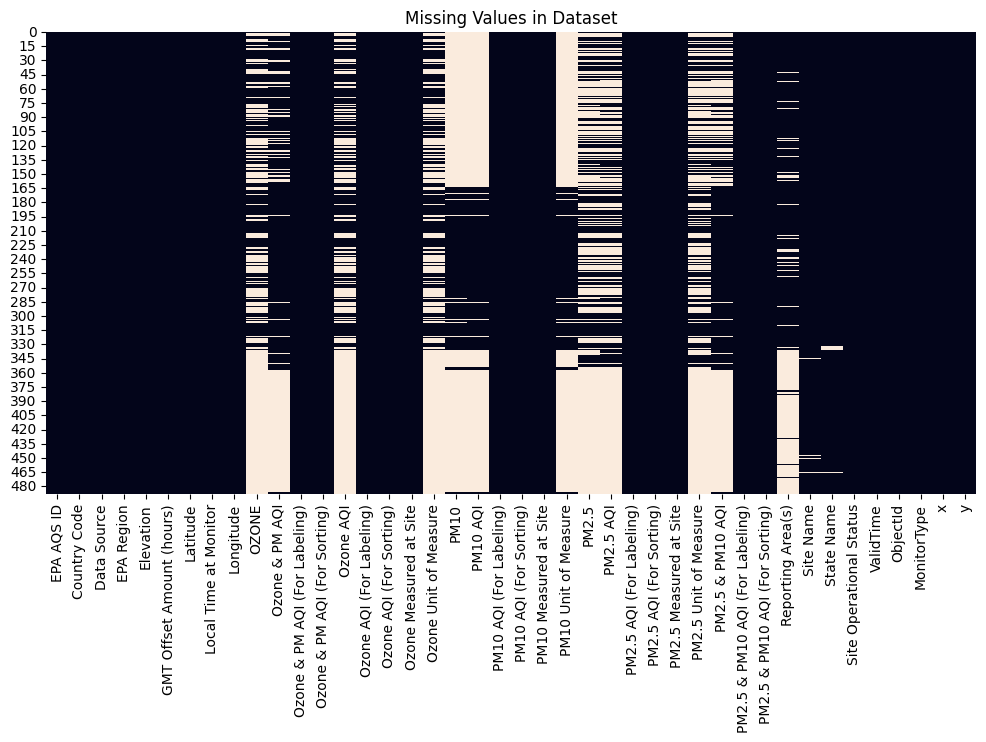

In [6]:
# Check dataset info
data.info()

# Quick statistics
data.describe()

# Missing values
missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values)

# Visualize missing values
plt.figure(figsize=(12,6))
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values in Dataset")
plt.show()

## Feature Selection & Data Cleaning
Select numeric features (`OZONE`, `PM2.5`, `PM10`) and the target (`Ozone & PM AQI`), and drop rows with missing values in these columns.


In [7]:
# Selecting numeric features and target
features = ['OZONE', 'PM2.5', 'PM10']
target = 'Ozone & PM AQI'

# Drop rows with missing values in selected columns
data_clean = data.dropna(subset=features + [target])

# Final feature/target selection
X = data_clean[features]
y = data_clean[target]

# Check shapes
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (75, 3)
Target shape: (75,)


##### Feature Selection Justification

OZONE, PM2.5, and PM10 were selected as the main predictors because they are standard pollutants commonly used in air quality monitoring and are directly related to AQI formation.

##### Data Cleaning Note
After removing rows with missing values in the selected features and target variable, the usable dataset reduced substantially. This ensures cleaner input for model training, but it may also reduce generalizability due to the smaller sample size.

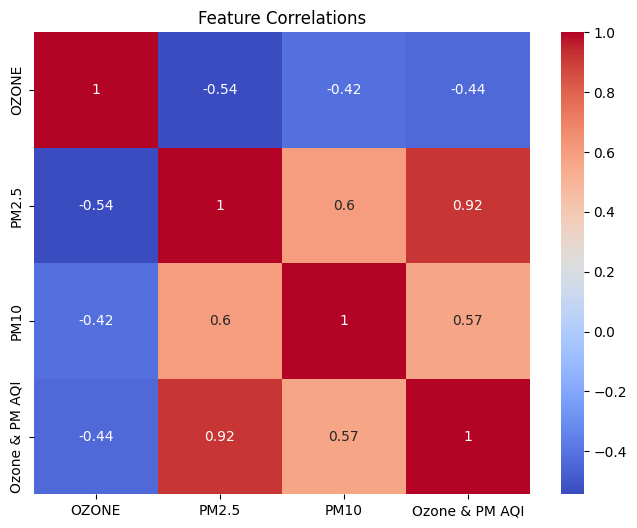

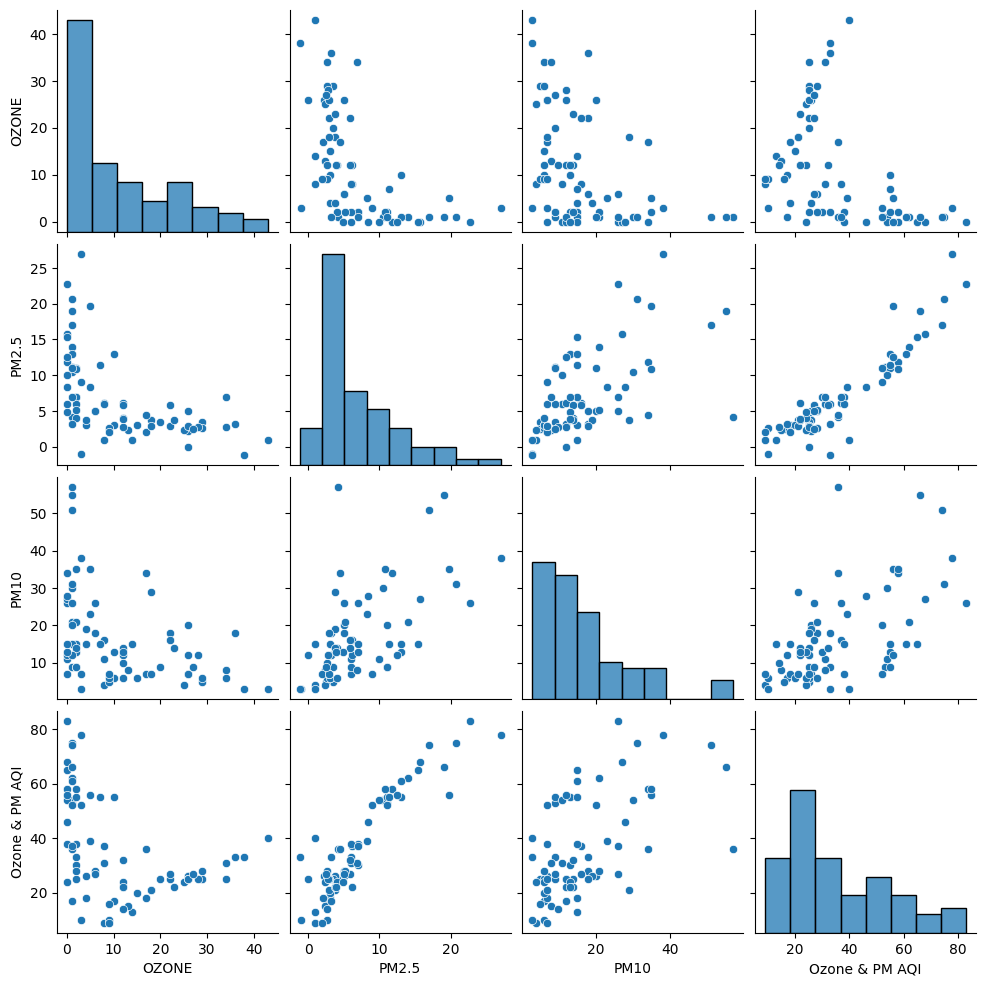

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(data_clean[features + [target]].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlations")
plt.show()

sns.pairplot(data_clean[features + [target]])
plt.show()


##### EDA Insight 

The correlation analysis indicates that PM2.5 has the strongest positive relationship with AQI, suggesting that it is the most influential pollutant in determining air quality levels. OZONE and PM10 show weaker relationships in comparison.

## Train-Test Split
Split the dataset into training and testing sets (80/20) for model evaluation.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


##### Feature Selection Justification

OZONE, PM2.5, and PM10 were selected as the main predictors because they are standard pollutants commonly used in air quality monitoring and are directly related to AQI formation.

## Linear Regression Model
Train a Linear Regression model to predict AQI based on the selected features.


In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = lr_model.predict(X_test)


## Model Evaluation
Evaluate the model using Mean Squared Error (MSE) and R² score, and visualize predicted vs actual AQI values.


In [12]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")


Mean Squared Error: 60.78
R2 Score: 0.62


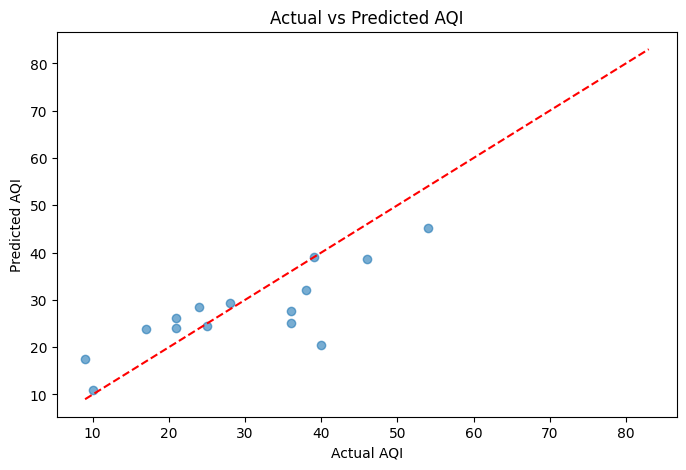

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # diagonal line
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()

### Predictive Data Modeling Plan – Air Quality Analysis

**Objective:** Predict AQI levels using pollutant concentrations (Ozone, PM2.5, PM10).

**Dataset:** US EPA AirNow (updated Feb 2024), collected continuously from multiple monitoring stations across the US.

**Features:**
- OZONE (ppb)
- PM2.5 (µg/m³)
- PM10 (µg/m³)

**Target:**
- Ozone & PM AQI

**Preprocessing:**
- Dropped rows with missing values in features/target
- Explored correlations and distributions

**Model Choice:**
- Linear Regression for numeric AQI prediction
- Simple, interpretable, baseline model for continuous target

**Evaluation Metrics:**
- Mean Squared Error (MSE)
- R² Score

**Next Steps:**
- Consider predicting AQI category (Good/Moderate/Unhealthy) with a classifier
- Experiment with other regression models (Random Forest, Gradient Boosting)



## Random Forest Model
Train a Random Forest Regressor to compare performance with Linear Regression.

In [14]:
# Initialize Random Forest
rf_model = RandomForestRegressor(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)


## Model Evaluation
Evaluate the model using Mean Squared Error (MSE) and R² score, and visualize predicted vs actual AQI values.


In [15]:
# Evaluate
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print(f"Mean Squared Error: {rf_mse:.2f}")
print(f"R2 Score: {rf_r2:.2f}")

Random Forest Results
Mean Squared Error: 36.95
R2 Score: 0.77


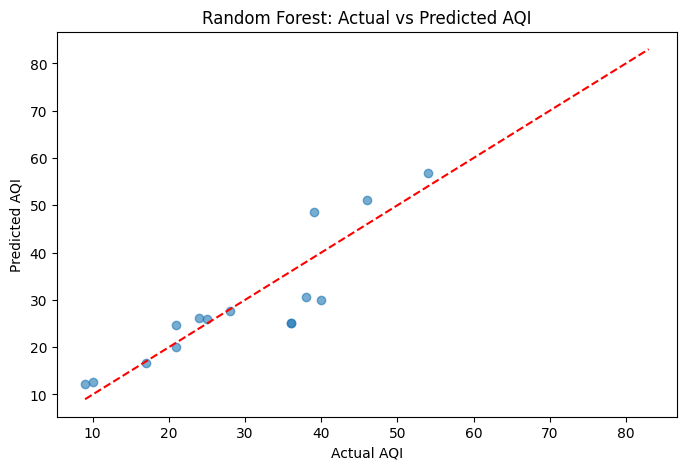

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Random Forest: Actual vs Predicted AQI")
plt.show()

## Model Comparison
Compare Linear Regression and Random Forest models.

In [17]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [mse, rf_mse],
    "R2 Score": [r2, rf_r2]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression,60.778184,0.617523
1,Random Forest,36.949847,0.767475


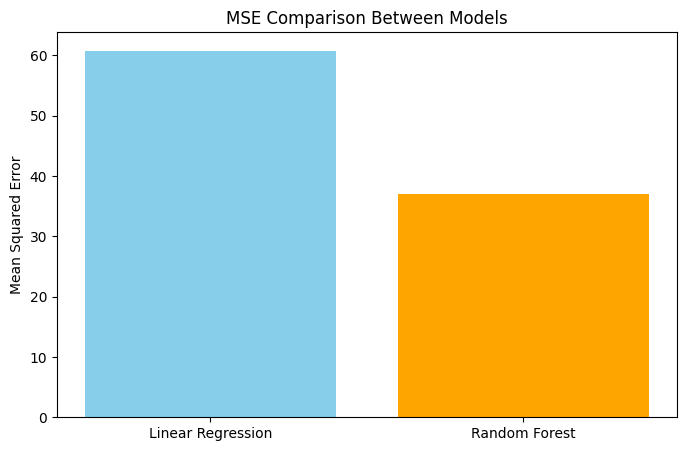

In [18]:
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["MSE"], color=['skyblue', 'orange'])
plt.ylabel("Mean Squared Error")
plt.title("MSE Comparison Between Models")
plt.show()

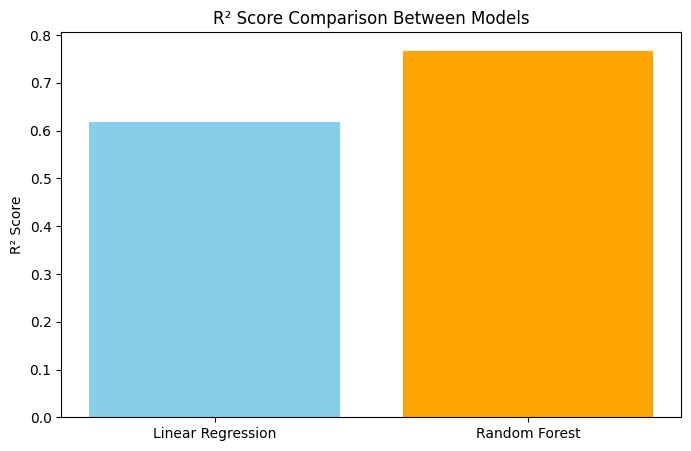

In [19]:
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["R2 Score"], color=['skyblue', 'orange'])
plt.ylabel("R² Score")
plt.title("R² Score Comparison Between Models")
plt.show()

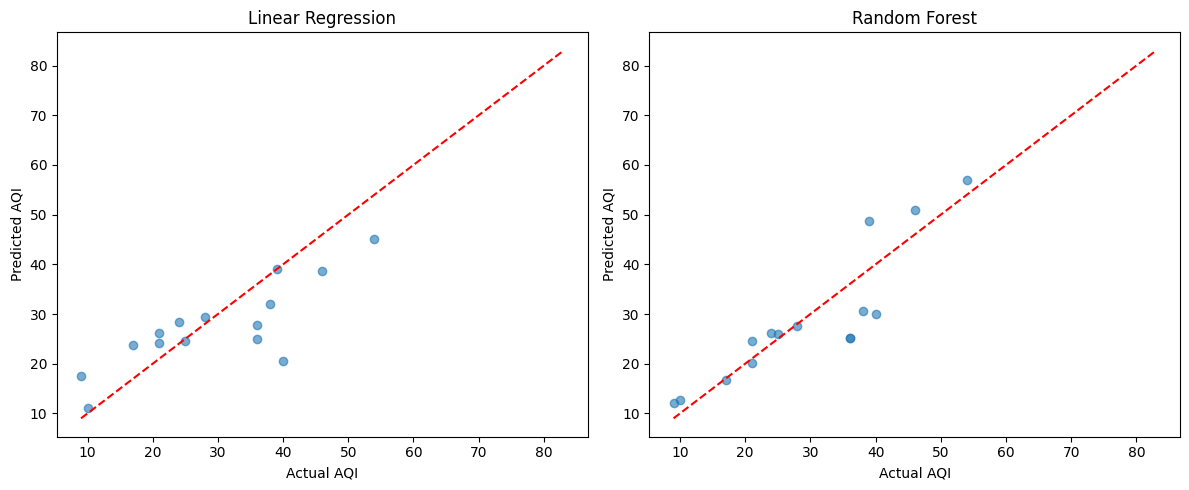

In [20]:
plt.figure(figsize=(12,5))

# Linear Regression
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Linear Regression")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

# Random Forest
plt.subplot(1,2,2)
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Random Forest")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.tight_layout()
plt.show()

In [21]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# Apply to predictions
y_pred_cat = [aqi_category(val) for val in y_pred]
rf_pred_cat = [aqi_category(val) for val in rf_pred]

# Create a small comparison dataframe
cat_comparison = pd.DataFrame({
    "Actual AQI": y_test,
    "Linear Predicted AQI": y_pred,
    "Linear Category": y_pred_cat,
    "RF Predicted AQI": rf_pred,
    "RF Category": rf_pred_cat
})
cat_comparison.head(10)

,Actual AQI,Linear Predicted AQI,Linear Category,RF Predicted AQI,RF Category
174,54.0,45.150548,Good,56.90,Moderate
315,25.0,24.485962,Good,25.90,Good
185,36.0,25.013407,Good,25.19,Good
167,9.0,17.524722,Good,12.13,Good
255,21.0,26.143404,Good,24.63,Good
313,21.0,24.096292,Good,20.11,Good
219,46.0,38.705503,Good,51.02,Moderate
189,40.0,20.552740,Good,30.01,Good
323,28.0,29.312925,Good,27.60,Good
316,24.0,28.480748,Good,26.13,Good


## Gradient Boosting Model

In [22]:
# Initialize Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict on test set
gb_pred = gb_model.predict(X_test)

## Model Evaluation
Evaluate the model using Mean Squared Error (MSE) and R² score, and visualize predicted vs actual AQI values.


In [23]:
# Evaluate Gradient Boosting
gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print(f"Mean Squared Error: {gb_mse:.2f}")
print(f"R2 Score: {gb_r2:.2f}")

Gradient Boosting Results
Mean Squared Error: 48.04
R2 Score: 0.70


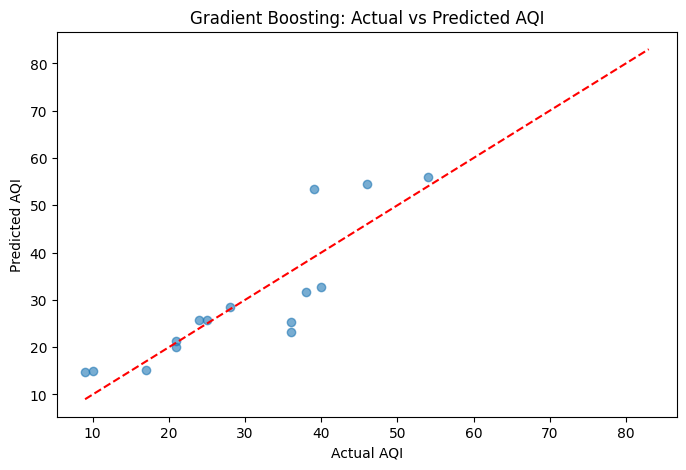

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, gb_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Gradient Boosting: Actual vs Predicted AQI")
plt.show()

## XGBoost Model
Train an XGBoost Regressor to compare performance with the other models.

In [25]:
# Initialize XGBoost
xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

In [32]:
# Evaluate XGBoost
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print(f"Mean Squared Error: {xgb_mse:.2f}")
print(f"R2 Score: {xgb_r2:.2f}")

XGBoost Results
Mean Squared Error: 28.19
R2 Score: 0.82


## Model Evaluation
Evaluate XGBoost using Mean Squared Error (MSE) and R² score, and visualize predicted vs actual AQI values.

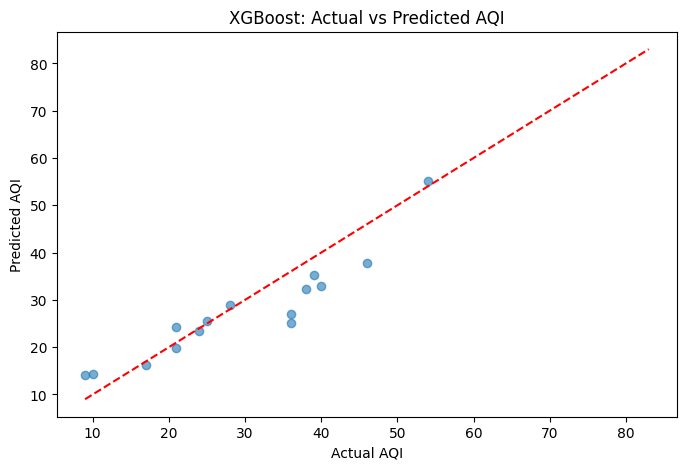

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, xgb_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("XGBoost: Actual vs Predicted AQI")
plt.show()

## Model Comparison
Compare Linear Regression, Random Forest, and Gradient Boosting using MSE and R² Score.


In [35]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
    "MSE": [mse, rf_mse, gb_mse, xgb_mse],
    "R2 Score": [r2, rf_r2, gb_r2, xgb_r2]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression,60.778184,0.617523
1,Random Forest,36.949847,0.767475
2,Gradient Boosting,48.035993,0.697709
3,XGBoost,28.187167,0.822618


##### Model Interpretation 

Tree-based ensemble models outperformed linear regression because they are better able to capture nonlinear relationships and complex interactions between pollutant variables and AQI.

##### Best Model 

XGBoost achieved the lowest Mean Squared Error and the highest R² score among all tested models, indicating that it provides the most accurate AQI predictions in this study.

## Visual Comparison

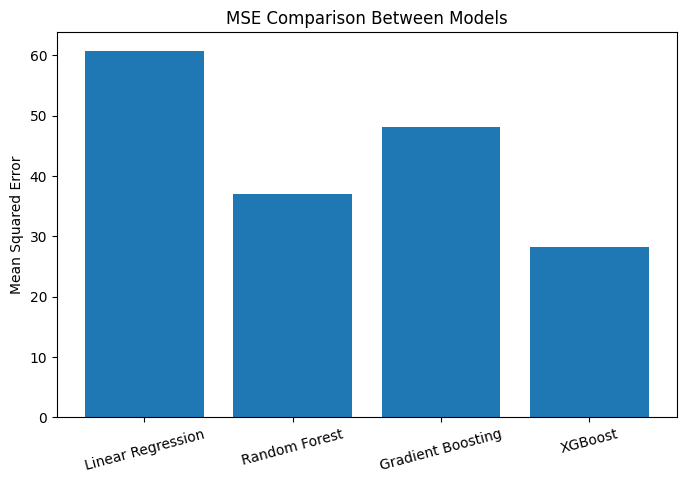

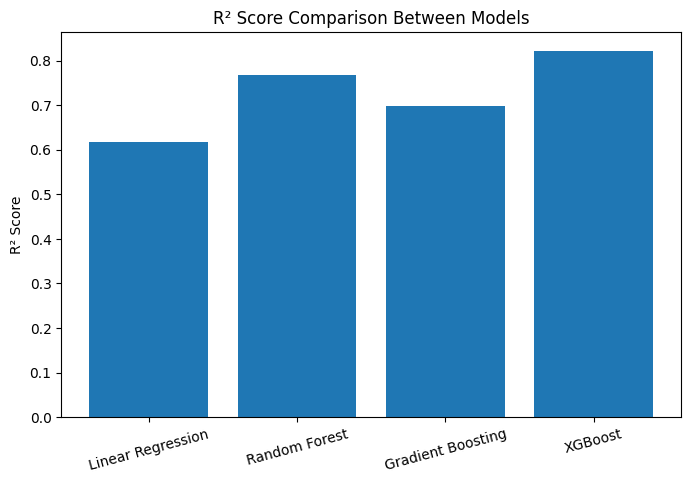

In [36]:
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["MSE"])
plt.ylabel("Mean Squared Error")
plt.title("MSE Comparison Between Models")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["R2 Score"])
plt.ylabel("R² Score")
plt.title("R² Score Comparison Between Models")
plt.xticks(rotation=15)
plt.show()

## Actual vs Predicted Plots

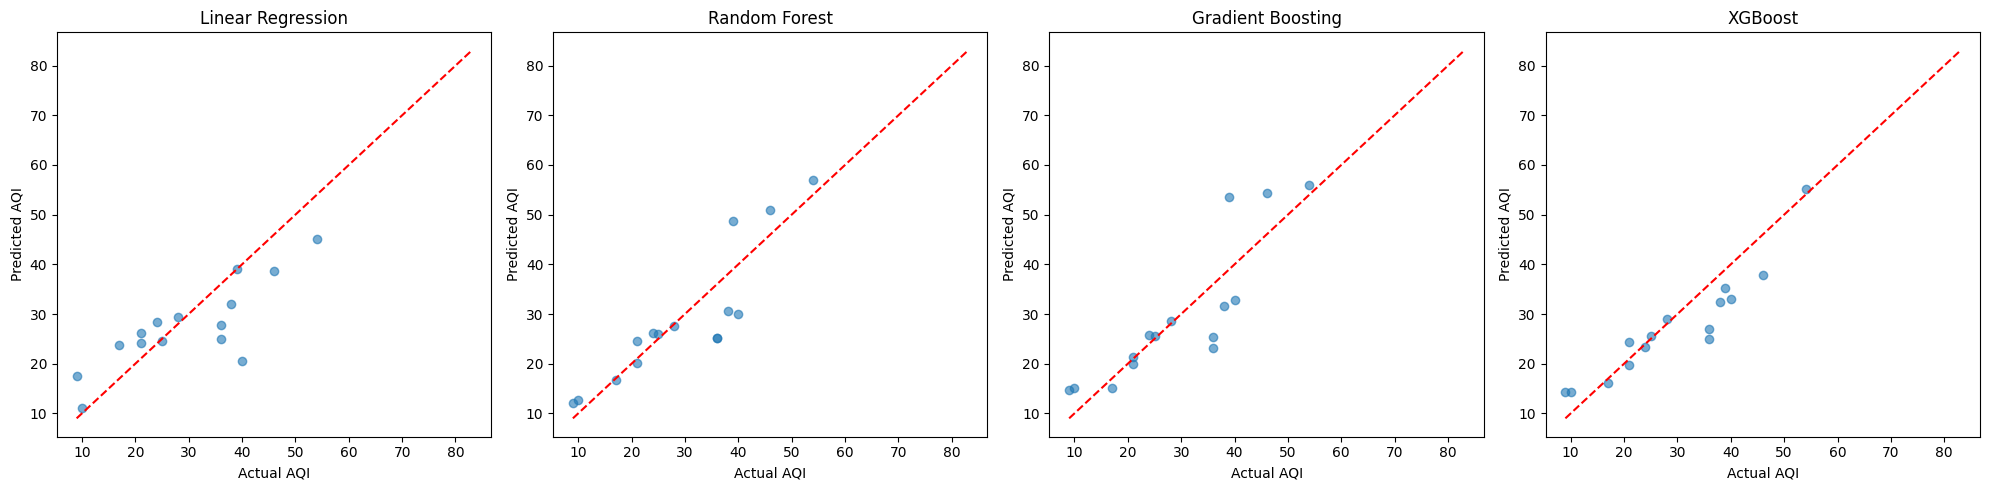

In [37]:
plt.figure(figsize=(20,5))

# Linear Regression
plt.subplot(1,4,1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Linear Regression")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

# Random Forest
plt.subplot(1,4,2)
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Random Forest")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

# Gradient Boosting
plt.subplot(1,4,3)
plt.scatter(y_test, gb_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Gradient Boosting")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

# XGBoost
plt.subplot(1,4,4)
plt.scatter(y_test, xgb_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("XGBoost")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.tight_layout()
plt.show()

## AQI Category Mapping

In [41]:
# Function to map numeric AQI to categories
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

# Apply category mapping
gb_pred_cat = [aqi_category(val) for val in gb_pred]
xgb_pred_cat = [aqi_category(val) for val in xgb_pred]

# Create a comparison dataframe
cat_comparison_all = pd.DataFrame({
    "Actual AQI": y_test,
    "Linear Predicted AQI": y_pred,
    "Linear Category": [aqi_category(val) for val in y_pred],
    "RF Predicted AQI": rf_pred,
    "RF Category": [aqi_category(val) for val in rf_pred],
    "GB Predicted AQI": gb_pred,
    "GB Category": gb_pred_cat,
    "XGB Predicted AQI": xgb_pred,
    "XGB Category": xgb_pred_cat
})

cat_comparison_all.head(10)

cat_comparison_all.head(10)

,Actual AQI,Linear Predicted AQI,Linear Category,RF Predicted AQI,RF Category,GB Predicted AQI,GB Category,XGB Predicted AQI,XGB Category
174,54.0,45.150548,Good,56.90,Moderate,55.896892,Moderate,55.187038,Moderate
315,25.0,24.485962,Good,25.90,Good,25.648292,Good,25.579235,Good
185,36.0,25.013407,Good,25.19,Good,25.430912,Good,27.083572,Good
167,9.0,17.524722,Good,12.13,Good,14.764666,Good,14.224339,Good
255,21.0,26.143404,Good,24.63,Good,21.287226,Good,24.367373,Good
313,21.0,24.096292,Good,20.11,Good,19.966213,Good,19.736486,Good
219,46.0,38.705503,Good,51.02,Moderate,54.423387,Moderate,37.897335,Good
189,40.0,20.552740,Good,30.01,Good,32.832132,Good,32.998959,Good
323,28.0,29.312925,Good,27.60,Good,28.538657,Good,28.992941,Good
316,24.0,28.480748,Good,26.13,Good,25.682122,Good,23.376770,Good


##### AQI Category Mapping

To improve interpretability, the continuous AQI predictions were converted into standard AQI categories such as Good, Moderate, Unhealthy, and Hazardous. This allowed classification-style evaluation using confusion matrices.

## Category Counts & Bar Plot

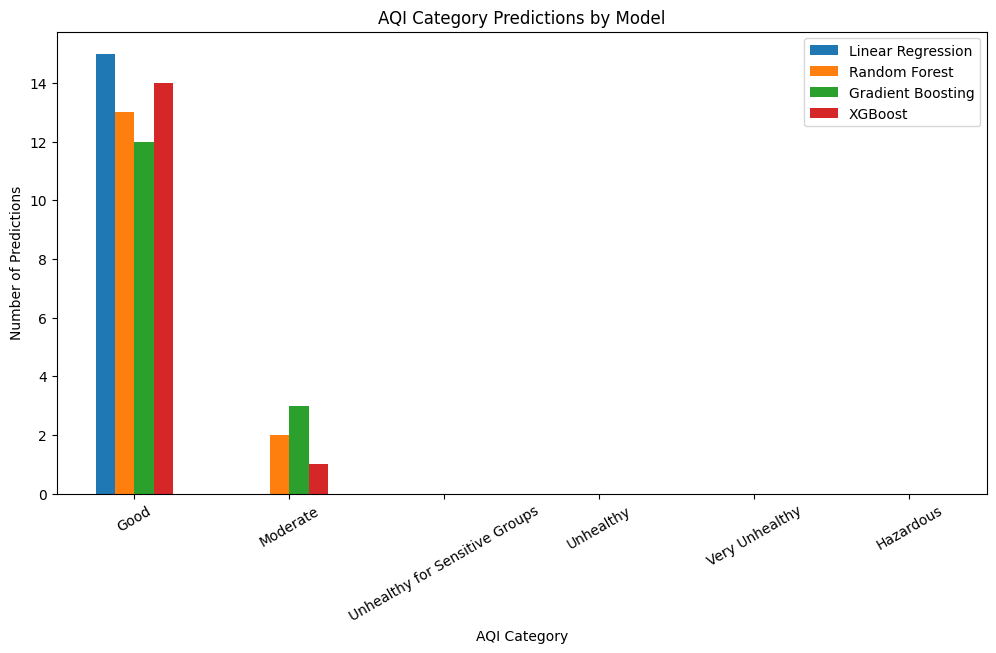

In [42]:
category_counts = pd.DataFrame({
    "Linear Regression": pd.Series(cat_comparison_all["Linear Category"]).value_counts(),
    "Random Forest": pd.Series(cat_comparison_all["RF Category"]).value_counts(),
    "Gradient Boosting": pd.Series(cat_comparison_all["GB Category"]).value_counts(),
    "XGBoost": pd.Series(cat_comparison_all["XGB Category"]).value_counts()
}).fillna(0)

category_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]
category_counts = category_counts.reindex(category_order)

category_counts.plot(kind='bar', figsize=(12,6))
plt.title("AQI Category Predictions by Model")
plt.xlabel("AQI Category")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=30)
plt.show()

## Combined Confusion Matrices

In [ ]:
actual_cat = [aqi_category(val) for val in y_test]

plt.figure(figsize=(24,6))

models = {
    "Linear Regression": y_pred_cat,
    "Random Forest": rf_pred_cat,
    "Gradient Boosting": gb_pred_cat,
    "XGBoost": xgb_pred_cat
}

categories = [
    "Good", "Moderate", "Unhealthy for Sensitive Groups",
    "Unhealthy", "Very Unhealthy", "Hazardous"
]

for i, (name, preds) in enumerate(models.items(), 1):
    cm = confusion_matrix(actual_cat, preds, labels=categories)
    plt.subplot(1, 4, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories)
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

NameError: name 'confusion_matrix' is not defined

<Figure size 2400x600 with 0 Axes>

## Feature Importance Analysis
Analyze which input features contribute most to AQI prediction.

### Random Forest Feature Importance


In [53]:
# Feature importance for Random Forest
rf_importances = rf_model.feature_importances_

rf_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

rf_feature_importance

,Feature,Importance
1,PM2.5,0.947484
0,OZONE,0.036705
2,PM10,0.015811


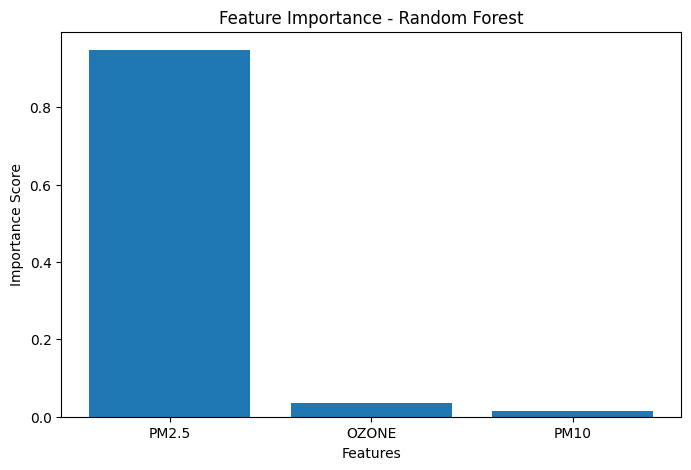

In [54]:
plt.figure(figsize=(8,5))
plt.bar(rf_feature_importance["Feature"], rf_feature_importance["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance - Random Forest")
plt.show()

### Feature Importance for XGBoost

In [55]:
# Feature importance for XGBoost
xgb_importances = xgb_model.feature_importances_

xgb_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_importances
}).sort_values(by="Importance", ascending=False)

xgb_feature_importance

,Feature,Importance
1,PM2.5,0.959918
0,OZONE,0.029074
2,PM10,0.011008


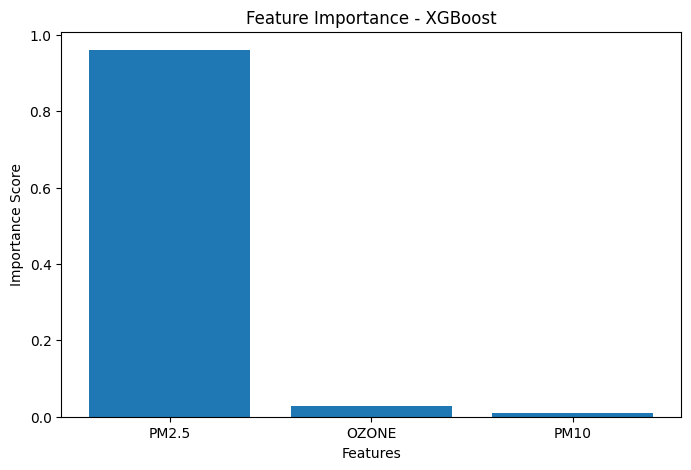

In [56]:
plt.figure(figsize=(8,5))
plt.bar(xgb_feature_importance["Feature"], xgb_feature_importance["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance - XGBoost")
plt.show()

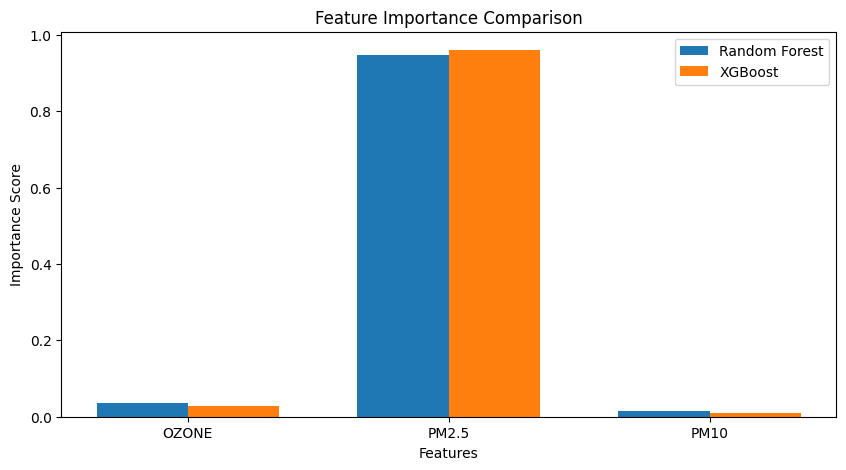

In [57]:
plt.figure(figsize=(10,5))

x = np.arange(len(features))
width = 0.35

plt.bar(x - width/2, rf_importances, width, label="Random Forest")
plt.bar(x + width/2, xgb_importances, width, label="XGBoost")

plt.xticks(x, features)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance Comparison")
plt.legend()
plt.show()

### Feature Importance Insights

Feature importance analysis was performed using tree-based models (Random Forest and XGBoost) to understand which pollutants contribute most to AQI prediction.

#### Random Forest Feature Importance

| Feature | Importance |
|--------|------------|
| PM2.5  | 0.947 |
| OZONE  | 0.037 |
| PM10   | 0.016 |

#### XGBoost Feature Importance

| Feature | Importance |
|--------|------------|
| PM2.5  | 0.960 |
| OZONE  | 0.029 |
| PM10   | 0.011 |

### Key Insights

- **PM2.5 is the dominant predictor** of AQI in both models.
- It contributes more than **94–96%** of the prediction importance.
- **OZONE and PM10 have significantly lower impact** on AQI in this dataset.
- The consistency between Random Forest and XGBoost strengthens the reliability of this finding.

### Interpretation

Feature importance analysis shows that PM2.5 contributes approximately 95% to AQI prediction in both Random Forest and XGBoost models. This indicates that fine particulate matter is the dominant pollutant affecting air quality, while OZONE and PM10 contribute much less.

## Hyperparameter Tuning
Tune the XGBoost model using GridSearchCV to improve predictive performance.

In [59]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2]
}

In [60]:
xgb_tune = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [61]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150}
Best Cross-Validation Score: 0.9160411412578071


In [62]:
best_xgb = grid_search.best_estimator_

# Predict with tuned model
best_xgb_pred = best_xgb.predict(X_test)

In [63]:
best_xgb_mse = mean_squared_error(y_test, best_xgb_pred)
best_xgb_r2 = r2_score(y_test, best_xgb_pred)

print("Tuned XGBoost Results")
print(f"Mean Squared Error: {best_xgb_mse:.2f}")
print(f"R2 Score: {best_xgb_r2:.2f}")

Tuned XGBoost Results
Mean Squared Error: 29.90
R2 Score: 0.81


In [64]:
tuning_comparison = pd.DataFrame({
    "Model": ["Original XGBoost", "Tuned XGBoost"],
    "MSE": [xgb_mse, best_xgb_mse],
    "R2 Score": [xgb_r2, best_xgb_r2]
})

tuning_comparison

,Model,MSE,R2 Score
0,Original XGBoost,28.187167,0.822618
1,Tuned XGBoost,29.898586,0.811848


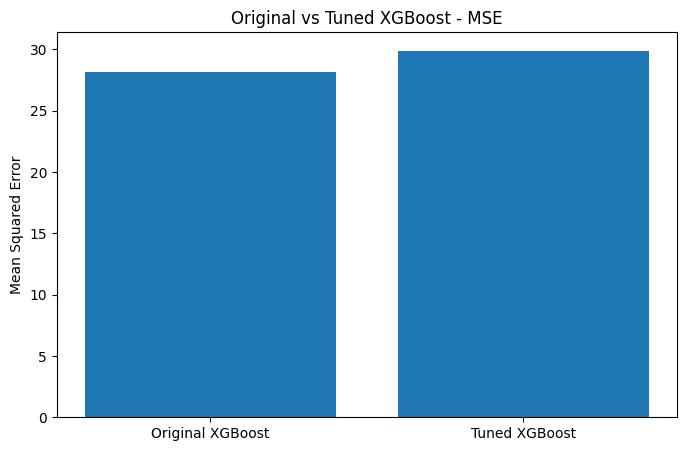

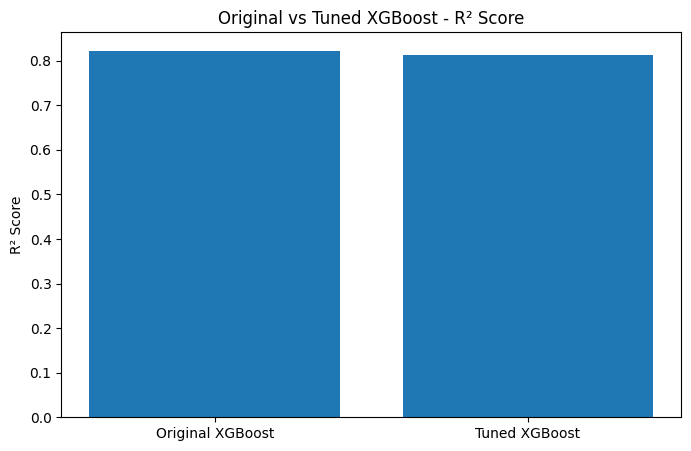

In [65]:
plt.figure(figsize=(8,5))
plt.bar(tuning_comparison["Model"], tuning_comparison["MSE"])
plt.ylabel("Mean Squared Error")
plt.title("Original vs Tuned XGBoost - MSE")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(tuning_comparison["Model"], tuning_comparison["R2 Score"])
plt.ylabel("R² Score")
plt.title("Original vs Tuned XGBoost - R² Score")
plt.show()

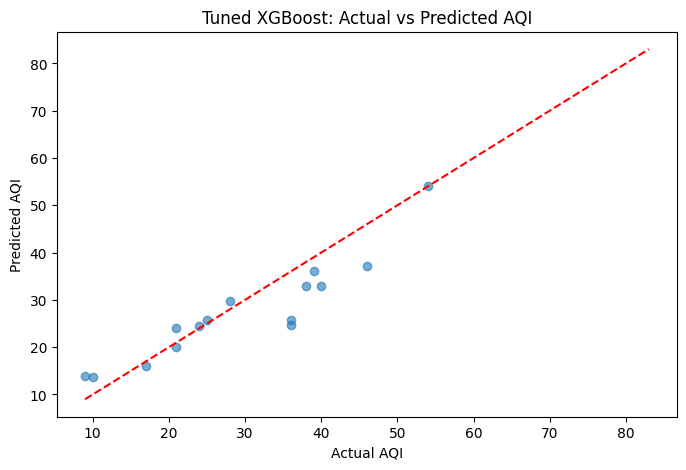

In [66]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, best_xgb_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Tuned XGBoost: Actual vs Predicted AQI")
plt.show()

### Hyperparameter Tuning Results

Hyperparameter tuning was performed on the XGBoost model using GridSearchCV with 3-fold cross-validation. The parameters tuned included the number of estimators, maximum tree depth, and learning rate.

The tuned model showed slightly lower performance compared to the original XGBoost model:

| Model | MSE | R² Score |
|------|-----|----------|
| Original XGBoost | 28.19 | 0.823 |
| Tuned XGBoost | 29.90 | 0.812 |

### Interpretation

- The tuned model did not outperform the original model.
- This suggests that the default or manually selected parameters were already close to optimal.
- It also indicates that the dataset may not require complex tuning to achieve strong performance.

### Conclusion

The original XGBoost model is retained as the final model due to its superior performance.

## Results & Interpretation

### Model Performance

| Model                  | MSE        | R² Score |
|------------------------|------------|----------|
| Linear Regression      | 60.78      | 0.618    |
| Random Forest          | 36.95      | 0.767    |
| Gradient Boosting      | 48.04      | 0.698    |
| XGBoost                | 28.19      | 0.823    |

### Insights

- **Linear Regression**:
  - Baseline model; interpretable but struggles with nonlinear relationships.
  - R² = 0.618 → explains about 62% of variance in AQI.
  - MSE = 60.78 → highest error among the models.

- **Random Forest**:
  - Strong performance with nonlinear data handling.
  - R² = 0.767 → explains about 77% of variance.
  - MSE = 36.95 → significantly better than Linear Regression.

- **Gradient Boosting**:
  - Performs better than Linear Regression but below Random Forest.
  - R² = 0.698 and MSE = 48.04.
  - Can be improved further with tuning.

- **XGBoost**:
  - Best performing model.
  - R² = 0.823 → explains over 82% of variance in AQI.
  - MSE = 28.19 → lowest error among all models.
  - Effectively captures complex nonlinear relationships between pollutants and AQI.


### Recommendation

- **Best numeric AQI prediction:** **XGBoost** (lowest MSE and highest R²).
- **Best for interpretability:** Linear Regression.
- **Best tree-based benchmark:** Random Forest.

### Limitations

**Limitation 1:** Although the dataset represents hourly air quality observations, this study used a random train-test split for baseline modeling. A time-based split would provide a more realistic evaluation for forecasting future AQI values.

**Limitation 2:** The number of usable observations decreased after removing missing values. While this improved data quality, it may limit the model’s ability to generalize to larger and more diverse air quality datasets.

### Real-World Application 

The developed AQI prediction model can support environmental monitoring systems by providing early warnings about air pollution levels. This can help public health agencies, local authorities, and citizens make informed decisions.

### Conclusion

This study demonstrates that machine learning can effectively predict AQI using pollutant concentrations such as OZONE, PM2.5, and PM10. Among all tested models, XGBoost achieved the best performance, indicating its strength in capturing nonlinear relationships within environmental data. Feature importance analysis revealed that PM2.5 is the dominant pollutant influencing AQI. Although the model performed well, future work should incorporate temporal validation and meteorological variables to improve realism and predictive performance.

### Future Work

- Incorporate variables such as temperature, humidity, and wind speed to improve model performance.  
- Apply time-series modeling techniques to better capture temporal dependencies in air quality data.  
- Use time-based validation instead of random train-test split for more realistic forecasting evaluation.  
- Expand the dataset to include more locations and longer time periods for improved generalization.  